# Home Credit Default Risk
### Author: Siqi Wang
### Dataset: Home Credit Group (Kaggle)
### Goal: Predict default risk using demographic, financial, and behavioral features.
### Date: October 2025

## 1. Introduction

Many people struggle to get loans due to insufficient or non-existent credit histories. And, unfortunately, this population is often taken advantage of by untrustworthy lenders.

Home Credit Group

Home Credit strives to broaden financial inclusion for the unbanked population by providing a positive and safe borrowing experience. In order to make sure this underserved population has a positive loan experience, Home Credit makes use of a variety of alternative data--including telco and transactional information--to predict their clients' repayment abilities.

While Home Credit is currently using various statistical and machine learning methods to make these predictions, they're challenging Kagglers to help them unlock the full potential of their data. Doing so will ensure that clients capable of repayment are not rejected and that loans are given with a principal, maturity, and repayment calendar that will empower their clients to be successful.

https://www.kaggle.com/c/home-credit-default-risk/

## 2. Data Loading and Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
pd.set_option('display.max_columns', None)

In [2]:
app_train = pd.read_csv("./home-credit-default-risk/application_train.csv")
app_test = pd.read_csv("./home-credit-default-risk/application_test.csv")
bureau = pd.read_csv("./home-credit-default-risk/bureau.csv")
bureau_balance = pd.read_csv("./home-credit-default-risk/bureau_balance.csv")
prev_app = pd.read_csv("./home-credit-default-risk/previous_application.csv")
installments = pd.read_csv("./home-credit-default-risk/installments_payments.csv")
credit_card = pd.read_csv("./home-credit-default-risk/credit_card_balance.csv")
pos_cash = pd.read_csv("./home-credit-default-risk/POS_CASH_balance.csv")

print(app_train.shape, app_test.shape)
app_train.head()

(307511, 122) (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 3. Data Cleaning

In [4]:
import numpy as np
import pandas as pd

def safe_div(a, b):
    out = np.divide(a, b, out=np.zeros_like(a, dtype=float), where=(b!=0))
    return out

# --- BUREAU + BUREAU_BALANCE ---
# 1) bureau 基础聚合 + 计数
buro = bureau.copy()
buro['IS_ACTIVE'] = (buro['CREDIT_ACTIVE'] == 'Active').astype('int8')
buro['IS_CLOSED'] = (buro['CREDIT_ACTIVE'] == 'Closed').astype('int8')

buro_agg = buro.groupby('SK_ID_CURR').agg(
    BURO_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BURO_DAYS_CREDIT_MAX=('DAYS_CREDIT', 'max'),
    BURO_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BURO_AMT_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BURO_AMT_CREDIT_SUM_SUM=('AMT_CREDIT_SUM', 'sum'),
    BURO_AMT_CREDIT_SUM_MAX=('AMT_CREDIT_SUM', 'max'),
    BURO_AMT_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BURO_AMT_CREDIT_SUM_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BURO_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE','mean'),
    BURO_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE','max'),
    BURO_CREDIT_DAY_OVERDUE_SUM=('CREDIT_DAY_OVERDUE','sum'),
    BURO_N_LOANS=('SK_ID_BUREAU','count'),
    BURO_N_ACTIVE=('IS_ACTIVE','sum'),
    BURO_N_CLOSED=('IS_CLOSED','sum')
).reset_index()

# 2) bureau_balance：状态占比 + “最近值” + “样本数”
bb = bureau_balance[['SK_ID_BUREAU','MONTHS_BALANCE','STATUS']].copy()
# 状态 one-hot 占比（对每个 SK_ID_BUREAU）
bb_stat = (bb
    .pivot_table(index='SK_ID_BUREAU', columns='STATUS', values='MONTHS_BALANCE', aggfunc='count')
    .fillna(0))
bb_stat = bb_stat.div(bb_stat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
bb_stat.columns = [f'BB_PCT_STATUS_{c}' for c in bb_stat.columns]
bb_cnt = bb.groupby('SK_ID_BUREAU').size().rename('BB_N_ROWS')

# 最近月份（最大 MONTHS_BALANCE）的状态是否逾期（>0）
idx_recent = bb.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].idxmax()
bb_recent = bb.loc[idx_recent, ['SK_ID_BUREAU','STATUS']].copy()
bb_recent['BB_RECENT_DPD_FLAG'] = bb_recent['STATUS'].isin(['1','2','3','4','5']).astype('int8')
bb_recent = bb_recent.drop(columns='STATUS').set_index('SK_ID_BUREAU')

bb_feat = (pd.concat([bb_stat, bb_cnt, bb_recent], axis=1)
           .reset_index())

# 汇回到 bureau，再到客户
buro_min = buro[['SK_ID_BUREAU','SK_ID_CURR']].copy()
bb_join = buro_min.merge(bb_feat, on='SK_ID_BUREAU', how='left')\
                  .drop(columns='SK_ID_BUREAU')
bb_agg = bb_join.groupby('SK_ID_CURR').agg(['mean','max','sum'])
bb_agg.columns = ['BB_' + c[0] + '_' + c[1].upper() for c in bb_agg.columns]
bb_agg = bb_agg.reset_index()

# --- INSTALLMENTS（分期） ---
ip = installments[['SK_ID_CURR','DAYS_INSTALMENT','DAYS_ENTRY_PAYMENT',
                   'AMT_INSTALMENT','AMT_PAYMENT']].copy()
ip['DPD'] = (ip['DAYS_ENTRY_PAYMENT'] - ip['DAYS_INSTALMENT']).clip(lower=0)
ip['DBD'] = (ip['DAYS_INSTALMENT'] - ip['DAYS_ENTRY_PAYMENT']).clip(lower=0)
ip['PAY_RATIO'] = safe_div(ip['AMT_PAYMENT'].values, ip['AMT_INSTALMENT'].replace(0, np.nan).values)

ip_agg = ip.groupby('SK_ID_CURR').agg(
    IP_DPD_MEAN=('DPD','mean'),
    IP_DPD_MAX=('DPD','max'),
    IP_DPD_SUM=('DPD','sum'),
    IP_DBD_MEAN=('DBD','mean'),
    IP_DBD_MAX=('DBD','max'),
    IP_DBD_SUM=('DBD','sum'),
    IP_PAY_RATIO_MEAN=('PAY_RATIO','mean'),
    IP_PAY_RATIO_MAX=('PAY_RATIO','max'),
    IP_N_PAYMENTS=('DPD','size'),
    IP_OVERDUE_RATE=('DPD', lambda s: (s>0).mean())
).reset_index()

# --- PREVIOUS APPLICATION（历史申请） ---
pa = prev_app[['SK_ID_CURR','NAME_CONTRACT_STATUS','AMT_CREDIT','AMT_ANNUITY',
               'DAYS_DECISION','CNT_PAYMENT','DAYS_FIRST_DRAWING','DAYS_FIRST_DUE',
               'DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']].copy()

pa = pa.replace({'DAYS_FIRST_DRAWING': {365243: np.nan},
                 'DAYS_FIRST_DUE': {365243: np.nan},
                 'DAYS_LAST_DUE_1ST_VERSION': {365243: np.nan},
                 'DAYS_LAST_DUE': {365243: np.nan},
                 'DAYS_TERMINATION': {365243: np.nan}})

pa['IS_APPROVED'] = (pa['NAME_CONTRACT_STATUS']=='Approved').astype('int8')
pa['IS_REFUSED']  = (pa['NAME_CONTRACT_STATUS']=='Refused').astype('int8')

g = pa.groupby('SK_ID_CURR')
pa_agg = pd.concat([
    g['AMT_CREDIT'].agg(['mean','max','min']).add_prefix('PA_CREDIT_'),
    g['AMT_ANNUITY'].agg(['mean','max']).add_prefix('PA_ANNUITY_'),
    g['CNT_PAYMENT'].agg(['mean','max']).add_prefix('PA_CNTPAY_'),
    g['IS_APPROVED'].mean().rename('PA_APPROVED_RATE'),
    g['IS_REFUSED'].mean().rename('PA_REFUSED_RATE'),
    g['DAYS_DECISION'].agg(['mean','min']).add_prefix('PA_DECISION_'),
    g['DAYS_DECISION'].min().rename('PA_LAST_DECISION_DAYS')  # 最近期（最接近0，数值最小）
], axis=1).reset_index()

# --- CREDIT CARD（信用卡） ---
cc = credit_card[['SK_ID_CURR','MONTHS_BALANCE','AMT_BALANCE',
                  'AMT_CREDIT_LIMIT_ACTUAL','AMT_DRAWINGS_CURRENT',
                  'AMT_PAYMENT_TOTAL_CURRENT','SK_DPD']].copy()
cc['UTIL'] = safe_div(cc['AMT_BALANCE'].values, (cc['AMT_CREDIT_LIMIT_ACTUAL'].values + 1e-6))

def recent_mean(df, n, key, col, name):
    return (df[df['MONTHS_BALANCE']>=-n]
            .groupby(key)[col].mean().rename(name).reset_index())

cc_agg = cc.groupby('SK_ID_CURR').agg(
    CC_BAL_MEAN=('AMT_BALANCE','mean'),
    CC_BAL_MAX=('AMT_BALANCE','max'),
    CC_LIMIT_MEAN=('AMT_CREDIT_LIMIT_ACTUAL','mean'),
    CC_LIMIT_MAX=('AMT_CREDIT_LIMIT_ACTUAL','max'),
    CC_DRAW_MEAN=('AMT_DRAWINGS_CURRENT','mean'),
    CC_DRAW_SUM=('AMT_DRAWINGS_CURRENT','sum'),
    CC_PAY_MEAN=('AMT_PAYMENT_TOTAL_CURRENT','mean'),
    CC_PAY_SUM=('AMT_PAYMENT_TOTAL_CURRENT','sum'),
    CC_DPD_MEAN=('SK_DPD','mean'),
    CC_DPD_MAX=('SK_DPD','max'),
    CC_N_ROWS=('SK_DPD','size')
).reset_index()
cc_agg['CC_UTILIZATION'] = safe_div(cc_agg['CC_BAL_MEAN'].values, (cc_agg['CC_LIMIT_MEAN'].values + 1e-6))

# 最近窗口
for n in (3,6,12):
    cc_agg = cc_agg.merge(recent_mean(cc, n, 'SK_ID_CURR','UTIL', f'CC_UTIL_{n}M'), on='SK_ID_CURR', how='left')
    cc_agg = cc_agg.merge(recent_mean(cc, n, 'SK_ID_CURR','SK_DPD', f'CC_DPD_{n}M'), on='SK_ID_CURR', how='left')

# --- POS_CASH ---
pos = pos_cash[['SK_ID_CURR','MONTHS_BALANCE','CNT_INSTALMENT_FUTURE','SK_DPD']].copy()
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_MONTHS_MAX=('MONTHS_BALANCE','max'),
    POS_MONTHS_MIN=('MONTHS_BALANCE','min'),
    POS_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE','mean'),
    POS_FUTURE_MAX=('CNT_INSTALMENT_FUTURE','max'),
    POS_DPD_MEAN=('SK_DPD','mean'),
    POS_DPD_MAX=('SK_DPD','max'),
    POS_OVERDUE_RATE=('SK_DPD', lambda s: (s>0).mean()),
    POS_N_ROWS=('SK_DPD','size')
).reset_index()

def recent_val(df, n, key, col, name):
    recent = df[df['MONTHS_BALANCE']>=-n]
    idx = recent.groupby(key)['MONTHS_BALANCE'].idxmax()
    return recent.loc[idx, [key, col]].rename(columns={col: name})

for n in (3,6):
    pos_agg = pos_agg.merge(recent_mean(pos, n, 'SK_ID_CURR','CNT_INSTALMENT_FUTURE', f'POS_FUTURE_{n}M'), on='SK_ID_CURR', how='left')
    tmp_last = recent_val(pos, n, 'SK_ID_CURR','SK_DPD', f'POS_DPD_LAST_{n}M')
    pos_agg = pos_agg.merge(tmp_last, on='SK_ID_CURR', how='left')

# === 一次性 merge 到 app ===
def merge_all(base):
    out = (base
        .merge(buro_agg, on='SK_ID_CURR', how='left')
        .merge(bb_agg,   on='SK_ID_CURR', how='left')
        .merge(ip_agg,   on='SK_ID_CURR', how='left')
        .merge(pa_agg,   on='SK_ID_CURR', how='left')
        .merge(cc_agg,   on='SK_ID_CURR', how='left')
        .merge(pos_agg,  on='SK_ID_CURR', how='left'))
    return out

app_train = merge_all(app_train)
app_test  = merge_all(app_test)

# 全量填 0（树模型安全），或者后面再用 train 中位数统一填充
fill_cols = app_train.columns.difference(['TARGET','SK_ID_CURR'])
app_train[fill_cols] = app_train[fill_cols].fillna(0)
app_test[fill_cols]  = app_test[fill_cols].fillna(0)


In [5]:
import numpy as np

def safe_div(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.zeros_like(num, dtype=float)
    np.divide(num, den, out=out, where=(den != 0) & np.isfinite(den))
    return out

def add_app_features(df):
    # 不删行：将异常性别标为缺失（或单独类别）
    # 可选做法1：缺失
    df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', np.nan)
    # 可选做法2（如果后面要映射成0/1）：把 XNA 当作 0 或额外类别

    # 统一处理 DAYS_EMPLOYED 的哨兵
    df['DAYS_EMPLOYED_CLEAN'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # 比例特征：使用安全除法
    df['INCOME_CREDIT_RATIO']  = safe_div(df['AMT_INCOME_TOTAL'], df['AMT_CREDIT'])
    df['ANNUITY_INCOME_RATIO'] = safe_div(df['AMT_ANNUITY'], df['AMT_INCOME_TOTAL'])

    # 年龄/工龄（年）
    df['AGE']            = -df['DAYS_BIRTH'] / 365.0
    df['EMPLOYED_YEARS'] = -df['DAYS_EMPLOYED_CLEAN'] / 365.0

    # （可选）加几个常用稳健特征
    df['CREDIT_TERM'] = safe_div(df['AMT_ANNUITY'], df['AMT_CREDIT'])              # 还款额/额度 ~ 期限 proxy
    df['PAYMENT_RATE'] = safe_div(df['AMT_ANNUITY'], df['AMT_CREDIT'])             # 与上等价，后续可二选一
    df['INCOME_PER_PERSON'] = safe_div(df['AMT_INCOME_TOTAL'], (1 + df['CNT_FAM_MEMBERS']))
    df['INCOME_PER_CHILD']  = safe_div(df['AMT_INCOME_TOTAL'], (1 + df['CNT_CHILDREN']))

    # （可选）对数前裁剪，防负数/inf
    df['INCOME_CREDIT_RATIO_LOG'] = np.log1p(np.clip(df['INCOME_CREDIT_RATIO'], 0, None))
    return df

app_train = add_app_features(app_train.copy())
app_test  = add_app_features(app_test.copy())

# 统一缺失填充（树模型直接 0 一般安全；更严谨可用 train 中位数填 test）
fill_cols = [c for c in app_train.columns if c not in ['TARGET','SK_ID_CURR']]
app_train[fill_cols] = app_train[fill_cols].fillna(0)
app_test[fill_cols]  = app_test[fill_cols].fillna(0)


In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# 1) 选择底层列
poly_input_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']

# 用 AGE_YEARS（正值，单位：年）
for df in [app_train, app_test]:
    if 'AGE_YEARS' not in df.columns:
        df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.0

# 2) y 备份
y = app_train['TARGET'].copy()

# 3) 仅对 poly 输入做填补（用 train 的统计量）
app_train_sub = app_train[poly_input_cols].copy()
app_test_sub  = app_test[poly_input_cols].copy()

train_median = app_train_sub.median()
app_train_sub = app_train_sub.fillna(train_median)
app_test_sub  = app_test_sub.fillna(train_median)  # 注意：用 train 统计量

# 4) 多项式交互（仅交互，degree=2）
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly.fit(app_train_sub)

train_poly = poly.transform(app_train_sub)
test_poly  = poly.transform(app_test_sub)

poly_cols = [f'POLY__{c}' for c in poly.get_feature_names_out(poly_input_cols)]

poly_train_df = pd.DataFrame(train_poly, columns=poly_cols, index=app_train.index)
poly_test_df  = pd.DataFrame(test_poly,  columns=poly_cols, index=app_test.index)

# 5) 合并回原表
app_train_poly = pd.concat([app_train, poly_train_df], axis=1)
app_test_poly  = pd.concat([app_test,  poly_test_df],  axis=1)

# 6) 列对齐 —— 用“左对齐”保留所有训练特征；test 中缺失列补 0
train_no_target = app_train_poly.drop(columns=['TARGET'])
train_no_target, app_test_poly = train_no_target.align(
    app_test_poly, join='left', axis=1, fill_value=0
)

# 把 TARGET 加回
app_train_poly_aligned = pd.concat([train_no_target, y], axis=1)

# 可选：确保 ID/行数完整
assert 'SK_ID_CURR' in app_train_poly_aligned.columns
assert 'SK_ID_CURR' in app_test_poly.columns
assert app_test_poly['SK_ID_CURR'].nunique() == app_test['SK_ID_CURR'].nunique()

# 如果后续模型用 app_train_poly_aligned
app_test = app_test_poly  # 仅当你后面都以这个 app_test 继续


C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_44196\189456848.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.0
C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_44196\189456848.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.0


In [7]:
# 1) 训练特征集合（以训练集为准）
features = [c for c in app_train_poly_aligned.columns if c not in ['TARGET','SK_ID_CURR']]

# 2) 训练集设计矩阵
X = app_train_poly_aligned[features].copy()

# 3) 测试集严格按训练列 reindex（缺的列会自动补 NaN；多余列被丢弃）
app_test_features = app_test.reindex(columns=features)

# 4) 缺失填充：
#    - 先用 train 的列中位数去填 test（推荐）
#    - train 也可以统一填 0（或中位数），保证和 test 一致
# 只对数值列取中位数
train_median = X.select_dtypes(include=[np.number]).median()

# 然后用中位数去填充，只在数值列上生效
X = X.fillna(train_median)
app_test_features = app_test_features.fillna(train_median)

# 5) 可选：清理 inf（极少见，但稳妥）
X = X.replace([np.inf, -np.inf], 0)
app_test_features = app_test_features.replace([np.inf, -np.inf], 0)

# 6) 目标
y = app_train_poly_aligned['TARGET'].astype(int)


## 3. Exploratory Data Analysis (EDA)

## 4. Feature Engineering

In [8]:
# 检查并转换类别特征为数值类型
def convert_categorical_features(df):
    # 将分类变量映射为数值型
    df['NAME_CONTRACT_TYPE'] = df['NAME_CONTRACT_TYPE'].map({'Cash loans': 0, 'Revolving loans': 1}).astype(float)
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1, 'XNA': 0}).astype(float)
    df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'N': 0, 'Y': 1}).astype(float)
    df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'N': 0, 'Y': 1}).astype(float)
    df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].map({'Unaccompanied': 0, 'Missing': 0, 'Other_A': 0, 'Other_B': 0, 'Spouse, partner': 1, 'Family': 1, 'Children': 1, 'Group of people': 1}).astype(float)
    df['NAME_INCOME_TYPE'] = df['NAME_INCOME_TYPE'].map(lambda v: 1.0 if v in {'Working', 'State servant', 'Commercial associate', 'Businessman', 'Pensioner'} else 0.0).astype(float)
    df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map({'Lower secondary': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}).astype(float)
    df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].map({'Single / not married': 0, 'Unknown': 0, 'Widow': 1, 'Separated': 1, 'Married': 2, 'Civil marriage': 2}).astype(float)
    df['NAME_HOUSING_TYPE'] = df['NAME_HOUSING_TYPE'].map({'House / apartment': 1, 'Co-op apartment': 1, 'With parents': 0, 'Rented apartment': 0, 'Municipal apartment': 0, 'Office apartment': 0}).astype(float)
    df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].map({'Managers': 2, 'Accountants': 2, 'Core staff': 2, 'High skill tech staff': 2, 'IT staff': 2, 'HR staff': 2, 'Medicine staff': 2, 'Sales staff': 1, 'Drivers': 1, 'Realty agents': 1, 'Secretaries': 1, 'Laborers': 0, 'Low-skill Laborers': 0, 'Cleaning staff': 0, 'Cooking staff': 0, 'Private service staff': 0, 'Waiters/barmen staff': 0, 'Security staff': 0, 'Missing': 0}).astype(float)
    
    def map_org_type(x):
        if x in {'Government', 'School', 'University', 'Security Ministries', 'Police', 'Military', 'Kindergarten'}: return 3
        if x in {'Bank', 'Insurance', 'Telecom', 'Electricity', 'Medicine'}: return 3
        if str(x).startswith(('Industry', 'Trade', 'Construction')): return 2
        if x in {'Business Entity Type 1', 'Business Entity Type 2', 'Business Entity Type 3', 'Services', 'Realtor', 'Restaurant', 'Hotel', 'Transport: type 1', 'Transport: type 2', 'Transport: type 3', 'Transport: type 4', 'Self-employed'}: return 1
        return 0
    df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].apply(map_org_type).astype(float)
    
    df['WEEKDAY_APPR_PROCESS_START'] = df['WEEKDAY_APPR_PROCESS_START'].map(lambda x: 1.0 if x in ['SATURDAY', 'SUNDAY'] else 0.0)
    df['FONDKAPREMONT_MODE'] = df['FONDKAPREMONT_MODE'].replace(0, 'Missing').map(lambda x: 1.0 if x in ['reg oper account', 'org spec account', 'reg oper spec account'] else 0.0)
    df['HOUSETYPE_MODE'] = df['HOUSETYPE_MODE'].replace(0, 'Missing').map({'terraced house': 1, 'block of flats': 1, 'specific housing': 0, 'Missing': 0}).astype(float)
    df['WALLSMATERIAL_MODE'] = df['WALLSMATERIAL_MODE'].replace(0, 'Missing').map(lambda x: 1.0 if x in ['Stone, brick', 'Block', 'Monolithic'] else 0.0)
    df['EMERGENCYSTATE_MODE'] = df['EMERGENCYSTATE_MODE'].replace(0, 'Missing').map({'No': 0.0, 'Missing': 0.0, 'Yes': 1.0})
    
    return df

# 处理 train 和 test
X = convert_categorical_features(app_train_poly_aligned[features])
T = convert_categorical_features(app_test_features)

# 填充缺失值：用训练集的中位数填充
train_median = X.select_dtypes(include=[np.number]).median()
X = X.fillna(train_median)
T = T.fillna(train_median)

# 目标
y = app_train_poly_aligned['TARGET'].astype(int)

# 现在 X 和 T 都已经被处理成数值类型，可以直接用于训练
# model.fit(X, y)
# model.predict(T)


C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_44196\3695318724.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NAME_CONTRACT_TYPE'] = df['NAME_CONTRACT_TYPE'].map({'Cash loans': 0, 'Revolving loans': 1}).astype(float)
C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_44196\3695318724.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1, 'XNA': 0}).astype(float)
C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_44196\3695318724.py:6: SettingWithCopy

In [9]:
# 仅对数值列计算中位数
train_median = X.select_dtypes(include=[np.number]).median()

# 用训练集中位数填充测试集
T.fillna(train_median, inplace=True)

# 检查测试集中是否缺列
missing_columns = set(X.columns) - set(T.columns)
extra_columns = set(T.columns) - set(X.columns)
print(f"❌ Missing in Test: {missing_columns}")
print(f"⚠️ Extra in Test: {extra_columns}")

# 最安全的做法：对齐列顺序
T = T.reindex(columns=X.columns)


❌ Missing in Test: set()
⚠️ Extra in Test: set()


## 5. Model Training and Validation

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

params = {
    "objective": "binary",
    "n_estimators": 5000,
    "learning_rate": 0.03,
    "max_depth": 15,
    "num_leaves": 64,
    "feature_fraction": 0.7,      # = colsample_bytree
    "bagging_fraction": 0.75,
    "bagging_freq": 3,
    "max_bin": 400,
    "reg_alpha": 1.0,             # L1
    "reg_lambda": 5.0,            # L2
    "min_child_samples": 120,
    "min_child_weight": 6,
    "n_jobs": -1,
    "random_state": 42,
    "verbose": -1
}


# 构造 LightGBM 数据集
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_valid, label=y_valid)

# 训练模型 + 早停（推荐加上）

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    num_boost_round=2000,                        # 给一个较大的上限
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(100)]  # 自动找最优轮数
)

# 用最佳轮数预测
y_pred = model.predict(X_valid, num_iteration=model.best_iteration)
auc = roc_auc_score(y_valid, y_pred)
print(f"Validation AUC: {auc:.4f}")



E:\ProgramData\Anaconda3\envs\torch\lib\site-packages\lightgbm\engine.py:172: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 200 rounds
[100]	training's binary_logloss: 0.235101	valid_1's binary_logloss: 0.242414
[200]	training's binary_logloss: 0.223761	valid_1's binary_logloss: 0.238374
[300]	training's binary_logloss: 0.215825	valid_1's binary_logloss: 0.237055
[400]	training's binary_logloss: 0.209057	valid_1's binary_logloss: 0.236502
[500]	training's binary_logloss: 0.20304	valid_1's binary_logloss: 0.236266
[600]	training's binary_logloss: 0.197363	valid_1's binary_logloss: 0.236161
[700]	training's binary_logloss: 0.19207	valid_1's binary_logloss: 0.236305
[800]	training's binary_logloss: 0.187066	valid_1's binary_logloss: 0.236336
Early stopping, best iteration is:
[608]	training's binary_logloss: 0.196938	valid_1's binary_logloss: 0.236159
Validation AUC: 0.7871


In [12]:
import pandas as pd
import lightgbm as lgb

def lgb_importance_df(model, importance_type="gain"):
    """
    支持两种模型：
      - Booster（lgb.train 或 clf.booster_）
      - LGBMClassifier / LGBMRegressor（sklearn API）
    importance_type: "split" 或 "gain"
    """
    # 拿到 booster
    booster = model.booster_ if hasattr(model, "booster_") else model
    if not isinstance(booster, lgb.Booster):
        raise TypeError("model 既不是 Booster 也不是已fit的 LGBMClassifier/LGBMRegressor")

    names = booster.feature_name()
    imps  = booster.feature_importance(importance_type=importance_type)
    df = pd.DataFrame({"feature": names, "importance": imps})
    return df.sort_values("importance", ascending=False).reset_index(drop=True)

# 用法：
imp_df = lgb_importance_df(model, importance_type="gain")  # 或 "split"
print(imp_df.head(10))   # 最重要Top10

# 取“倒数”最不重要的20个特征名
least_20 = imp_df.sort_values("importance", ascending=True).head(20)["feature"].tolist()
print("最不重要的20个特征：", least_20)


                           feature    importance
0  POLY__EXT_SOURCE_2_EXT_SOURCE_3  74718.771474
1     POLY__EXT_SOURCE_2_AGE_YEARS  27728.686646
2                     EXT_SOURCE_3  24329.713428
3                      CREDIT_TERM  18333.120265
4                     EXT_SOURCE_2  15003.122788
5  POLY__EXT_SOURCE_1_EXT_SOURCE_2   9934.678703
6                      AMT_ANNUITY   9580.433332
7                  IP_OVERDUE_RATE   9529.293570
8                  POS_FUTURE_MEAN   8731.500378
9     POLY__EXT_SOURCE_3_AGE_YEARS   8545.513977
最不重要的20个特征： ['FLAG_DOCUMENT_21', 'FLAG_DOCUMENT_15', 'BB_BB_RECENT_DPD_FLAG_SUM', 'BB_BB_PCT_STATUS_3_MAX', 'NAME_INCOME_TYPE', 'FONDKAPREMONT_MODE', 'BURO_CREDIT_DAY_OVERDUE_SUM', 'FLAG_MOBIL', 'FLAG_DOCUMENT_9', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_5']


In [13]:
X = X.drop(columns=least_20, errors='ignore')
T = T.drop(columns=least_20, errors='ignore')


T = T.reindex(columns=X.columns)

train_median = X.select_dtypes(include=[np.number]).median()
X = X.fillna(train_median)
T = T.fillna(train_median)


In [14]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

params = {
    "objective": "binary",
    "n_estimators": 5000,      
    "learning_rate": 0.02,
    "max_depth": 13,
    "num_leaves": 30,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.75,
    "bagging_freq": 3,
    "max_bin": 500,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "min_child_samples": 200,
    "min_child_weight": 12,
    "scale_pos_weight":0.1* len(y_train[y_train==0]) / len(y_train[y_train==1]),
    "n_jobs": -1,
    "random_state": 42,
    "verbose": -1,
}

clf = LGBMClassifier(**params)

# 早停 + 记录 AUC
clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_names=['train','valid'],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(100)]
)



Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.769836	train's binary_logloss: 0.246243	valid's auc: 0.761633	valid's binary_logloss: 0.248024
[200]	train's auc: 0.789706	train's binary_logloss: 0.238193	valid's auc: 0.77493	valid's binary_logloss: 0.242105
[300]	train's auc: 0.801746	train's binary_logloss: 0.233466	valid's auc: 0.781187	valid's binary_logloss: 0.239479
[400]	train's auc: 0.81102	train's binary_logloss: 0.229911	valid's auc: 0.784416	valid's binary_logloss: 0.23811
[500]	train's auc: 0.818965	train's binary_logloss: 0.226957	valid's auc: 0.786526	valid's binary_logloss: 0.237291
[600]	train's auc: 0.825769	train's binary_logloss: 0.224418	valid's auc: 0.787825	valid's binary_logloss: 0.236813
[700]	train's auc: 0.831915	train's binary_logloss: 0.222124	valid's auc: 0.788446	valid's binary_logloss: 0.236571
[800]	train's auc: 0.837572	train's binary_logloss: 0.21996	valid's auc: 0.789216	valid's binary_logloss: 0.236298
[900]	train's 

LGBMClassifier(bagging_fraction=0.75, bagging_freq=3, feature_fraction=0.7,
               learning_rate=0.02, max_bin=500, max_depth=13,
               min_child_samples=200, min_child_weight=12, n_estimators=5000,
               n_jobs=-1, num_leaves=30, objective='binary', random_state=42,
               reg_alpha=1.0, reg_lambda=5.0,
               scale_pos_weight=1.1387109768378652, verbose=-1)

In [15]:
len(T.columns)

217

### Emsemble Models (CatBoost + LightGBM + XGBoost)

In [30]:
# pip install xgboost catboost lightgbm scikit-learn
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier

import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb


# ========== 1) 训练 XGBoost ==========
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=4000,
    learning_rate=0.02,
    max_depth=12,
    subsample=0.75,
    colsample_bytree=0.7,
    reg_alpha=3.0,
    reg_lambda=5.0,
    min_child_weight=6,
    # 如果可用 GPU，可改为 'gpu_hist'
    tree_method="gpu_hist",
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_metric="auc",
    verbose=False,
    early_stopping_rounds=200
)

# ========== 2) 训练 CatBoost ==========
# 自动识别类别列（若 X 为 numpy 或没有类别列，会得到空列表）
if isinstance(X_train, pd.DataFrame):
    cat_features = [i for i, dt in enumerate(X_train.dtypes) if str(dt) in ["category", "object"]]
else:
    cat_features = []

cat_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=4000,
    learning_rate=0.02,
    depth=10,
    l2_leaf_reg=4.0,
    random_seed=42,
    od_type="Iter",
    od_wait=200,
    verbose=False,
    task_type="GPU",  # 如果有 GPU，取消注释
)

cat_clf = CatBoostClassifier(**cat_params)

train_pool = Pool(X_train, y_train, cat_features=cat_features if cat_features else None)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features if cat_features else None)

cat_clf.fit(train_pool, eval_set=valid_pool, use_best_model=True, verbose=False)


E:\ProgramData\Anaconda3\envs\torch\lib\site-packages\xgboost\sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
E:\ProgramData\Anaconda3\envs\torch\lib\site-packages\xgboost\sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
E:\ProgramData\Anaconda3\envs\torch\lib\site-packages\xgboost\core.py:160: UserWarning: [20:52:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
Default metric perio

In [17]:

# ========== 3) 各模型验证集概率 ==========
# LightGBM（lgb.train）预测默认就是概率（sigmoid 后）
p_lgb = clf.predict_proba(X_valid, num_iteration=clf.best_iteration_)[:, 1]
# XGBoost
p_xgb = xgb_clf.predict_proba(X_valid)[:, 1]
# CatBoost
p_cat = cat_clf.predict_proba(valid_pool)[:, 1]

# ========== 4) 简单加权平均融合 ==========
# 先给个经验权重（你可以依据单模 AUC/PR 调整）
w_lgb, w_xgb, w_cat = 0.4, 0.3, 0.3
p_blend = w_lgb * p_lgb + w_xgb * p_xgb + w_cat * p_cat

def eval_all(name, y_true, p):
    print(f"[{name}] AUC={roc_auc_score(y_true, p):.6f}  AP={average_precision_score(y_true, p):.6f}  LogLoss={log_loss(y_true, p):.6f}")

print("=== 单模型表现 ===")
eval_all("LightGBM", y_valid, p_lgb)
eval_all("XGBoost", y_valid, p_xgb)
eval_all("CatBoost", y_valid, p_cat)

print("\n=== 融合表现（加权平均） ===")
eval_all("Blend(w-avg)", y_valid, p_blend)

# ========== 5) 二层 Stacking（可选） ==========
# 用三模型的 oof/meta 特征进行二层学习；这里为了快速演示，直接在验证集上用三者概率做特征
# 更严谨做法：在训练集上做K折生成OOF特征，再在验证/测试上做平均预测。
meta_X_valid = np.vstack([p_lgb, p_xgb, p_cat]).T

stacker = LogisticRegression(
    solver="liblinear",
    C=1.0,
    random_state=42
)
stacker.fit(meta_X_valid, y_valid)  # 演示：这里用 valid 拟合会有信息泄露；正式流程请用K折OOF
p_stack = stacker.predict_proba(meta_X_valid)[:, 1]

print("\n=== Stacking（二层LR，演示版） ===")
eval_all("Stack(LR on probs)", y_valid, p_stack)


E:\ProgramData\Anaconda3\envs\torch\lib\site-packages\xgboost\core.py:160: UserWarning: [20:40:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
E:\ProgramData\Anaconda3\envs\torch\lib\site-packages\xgboost\core.py:160: UserWarning: [20:40:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set th

=== 单模型表现 ===
[LightGBM] AUC=0.791638  AP=0.290821  LogLoss=0.235415
[XGBoost] AUC=0.788088  AP=0.285186  LogLoss=0.236749
[CatBoost] AUC=0.787464  AP=0.288355  LogLoss=0.236525

=== 融合表现（加权平均） ===
[Blend(w-avg)] AUC=0.792204  AP=0.292789  LogLoss=0.234857

=== Stacking（二层LR，演示版） ===
[Stack(LR on probs)] AUC=0.792235  AP=0.293032  LogLoss=0.241332


## Confusion Matrix

Validation AUC: 0.7922
Accuracy: 0.9194
Precision: 0.5053
Recall: 0.0961
F1-score: 0.1614
Best iteration: 2111


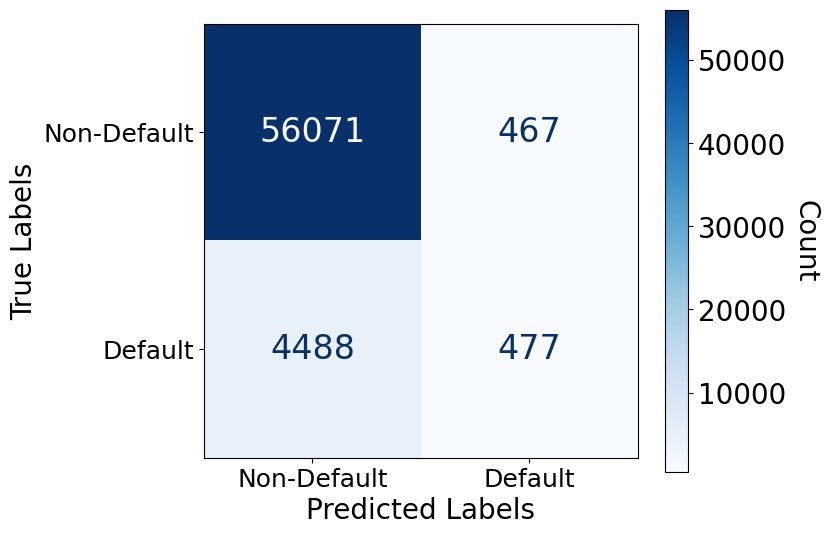

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_stack = stacker.predict(meta_X_valid)


auc = roc_auc_score(y_valid, p_stack)
acc = accuracy_score(y_valid, label_stack)
precision = precision_score(y_valid, label_stack)
recall = recall_score(y_valid, label_stack)
f1 = f1_score(y_valid, label_stack)

print(f"Validation AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Best iteration: {clf.best_iteration_}")

cm = confusion_matrix(y_valid, label_stack)

# 绘制混淆矩阵
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)

# 修改矩阵内数字字体大小
for text in ax.texts:
    text.set_fontsize(24)

# 修改坐标轴字体
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlabel('Predicted Labels', fontsize=20)
ax.set_ylabel('True Labels', fontsize=20)

# 修改右侧 colorbar 的字体大小
cbar = ax.get_figure().axes[-1]  # colorbar 在最后一个 axes 中
cbar.tick_params(labelsize=20)   # 调整 colorbar 刻度字体
cbar.set_ylabel('Count', fontsize=20, rotation=270, labelpad=24)  # 加上标签

# 保存图像
# plt.tight_layout()
plt.savefig("confusion_matrix.pdf", bbox_inches='tight', dpi=300)
plt.show()


In [25]:

# ========== 3) 各模型验证集概率 ==========
# LightGBM（lgb.train）预测默认就是概率（sigmoid 后）
p_lgb = clf.predict_proba(T, num_iteration=clf.best_iteration_)[:, 1]
# XGBoost
p_xgb = xgb_clf.predict_proba(T)[:, 1]
# CatBoost
p_cat = cat_clf.predict_proba(T)[:, 1]


T_p_stack = stacker.predict_proba(np.vstack([p_lgb, p_xgb, p_cat]).T)[:, 1]

submission = pd.DataFrame({
    "SK_ID_CURR": app_test["SK_ID_CURR"],
    "TARGET": T_p_stack  # 使用 Stacking 得到的最终预测概率
})

# 生成提交文件
submission = pd.DataFrame({
    "SK_ID_CURR": app_test["SK_ID_CURR"],
    "TARGET": T_p_stack  # 使用 Stacking 得到的最终预测概率
})

submission.to_csv("/kaggle/working/submission.csv", index=False)
submission
print("✅ submission.csv 已保存！")


✅ submission.csv 已保存！


### LightGBM

In [20]:
# 用最佳轮数做预测（sklearn 会自动用 best_iteration_）
y_pred_prob = clf.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, y_pred_prob)
print("Validation AUC:", round(auc, 4))
print("Best iteration:", clf.best_iteration_)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 用最佳轮数预测（sklearn 接口自动使用 best_iteration_）
y_pred_prob = clf.predict_proba(X_valid)[:, 1]
y_pred_label = (y_pred_prob >= 0.5).astype(int)

# 各类指标
auc = roc_auc_score(y_valid, y_pred_prob)
acc = accuracy_score(y_valid, y_pred_label)
precision = precision_score(y_valid, y_pred_label)
recall = recall_score(y_valid, y_pred_label)
f1 = f1_score(y_valid, y_pred_label)

print(f"Validation AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Best iteration: {clf.best_iteration_}")

# 可选：打印混淆矩阵或分类报告
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_pred_label))

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_label, target_names=["Non-default", "Default"]))


Validation AUC: 0.7916
Best iteration: 2111
Validation AUC: 0.7916
Accuracy: 0.9196
Precision: 0.5178
Recall: 0.0614
F1-score: 0.1098
Best iteration: 2111

Confusion Matrix:
[[56254   284]
 [ 4660   305]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.92      0.99      0.96     56538
     Default       0.52      0.06      0.11      4965

    accuracy                           0.92     61503
   macro avg       0.72      0.53      0.53     61503
weighted avg       0.89      0.92      0.89     61503



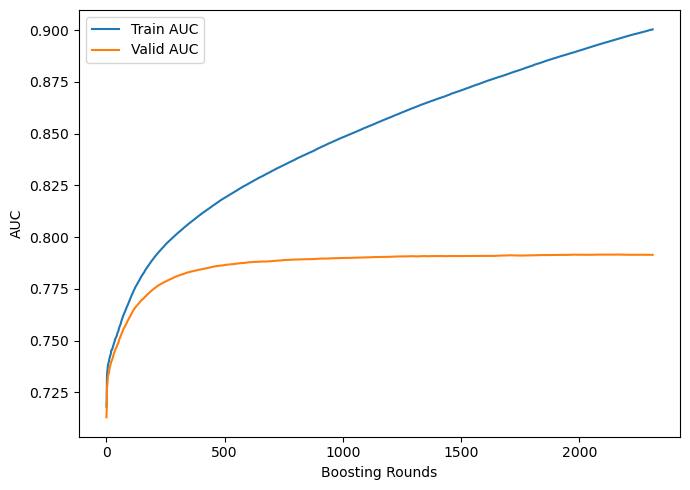

In [18]:
er = clf.evals_result_
train_auc = er['train']['auc']
valid_auc = er['valid']['auc']

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(train_auc, label='Train AUC')
plt.plot(valid_auc, label='Valid AUC')
plt.xlabel('Boosting Rounds')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Feature Importance and Interpretation

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# 绘制特征重要性
ax = lgb.plot_importance(clf, max_num_features=10, importance_type='gain', figsize=(9, 9))

# 放大 x, y 轴的 label 和 ticks 字号
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel('Importance', fontsize=24)
ax.set_ylabel('', fontsize=24)

# 旋转 y 轴和 x 轴标签
ax.set_yticklabels(ax.get_yticklabels(), rotation=12, fontsize=22)
ax.set_xticklabels(ax.get_xticklabels(), rotation=12, fontsize=20)

# 去掉标题
ax.set_title('')

# 去掉显示的具体 importance 数值
for text in ax.texts:
    text.set_visible(False)

# 保存图像
# plt.tight_layout()
plt.savefig("feature_importance.pdf", bbox_inches='tight', dpi=300)
plt.show()


## SHAP Plot

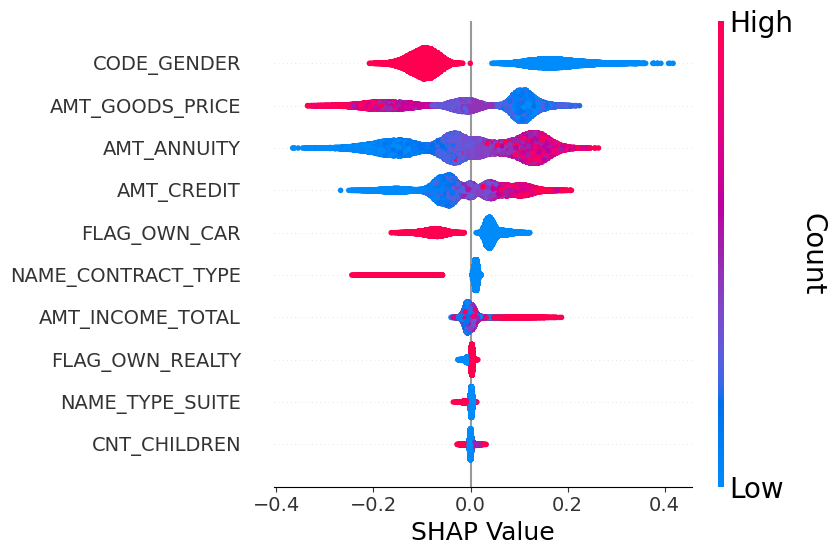

In [403]:
import shap
import matplotlib.pyplot as plt

# 初始化shap
shap.initjs()

# 计算SHAP值
explainer = shap.TreeExplainer(clf)  # clf 是已训练的 LightGBM 模型
shap_values = explainer.shap_values(X_valid)

# 如果是二分类任务，shap_values 是一个 list，取第二类（正类）那一项
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# 获取特征重要性前 N 个
top_n_features = 10  # 可调整显示特征数量
shap_values_top_n = shap_values[:, :top_n_features]
X_valid_top_n = X_valid.iloc[:, :top_n_features]

# 创建 summary plot
shap.summary_plot(shap_values_top_n, X_valid_top_n, feature_names=X_valid_top_n.columns, show=False)

# 获取当前的轴（ax）
ax = plt.gca()

# Adjust x and y ticks specifically for the summary plot
plt.xticks(fontsize=16)  # Set xticks font size
plt.yticks(fontsize=16)  # Set yticks font size

# Set labels font size
plt.xlabel("SHAP Value", fontsize=18)
plt.ylabel("", fontsize=24)

# 修改右侧 colorbar 的字体大小
cbar = ax.get_figure().axes[-1]  # colorbar 在最后一个 axes 中
cbar.tick_params(labelsize=20)   # 调整 colorbar 刻度字体
cbar.set_ylabel('Count', fontsize=20, rotation=270, labelpad=24)  # 加上标签

# 调整 bar 的刻度字体大小
ax.tick_params(axis='x', labelsize=14)  # x-axis tick font size
ax.tick_params(axis='y', labelsize=14)  # y-axis tick font size

# 调整保存的图像大小
plt.savefig("shap_feature_importance.pdf", bbox_inches='tight', dpi=300)
plt.show()


# Comparison Experiment

### (1) XGBoost

In [21]:
from xgboost import XGBClassifier

param = {
    'eta': 0.3, 
    'max_depth': 31,  
    'num_class': 2,
    'n_estimators': 200}

xgb_clf = XGBClassifier(scale_pos_weight=13, random_state=42)
xgb_clf.fit(X_train, y_train)
# print("Validation AUC:", auc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [32]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 用最佳轮数预测（sklearn 接口自动使用 best_iteration_）
xgb_y_pred_prob = xgb_clf.predict_proba(X_valid)[:, 1]
xgb_y_pred_label = (xgb_y_pred_prob >= 0.5).astype(int)

# 各类指标
xgb_auc = roc_auc_score(y_valid, xgb_y_pred_prob)
xgb_acc = accuracy_score(y_valid, xgb_y_pred_label)
xgb_precision = precision_score(y_valid, xgb_y_pred_label)
xgb_recall = recall_score(y_valid, xgb_y_pred_label)
xgb_f1 = f1_score(y_valid, xgb_y_pred_label)

print(f"Validation AUC: {xgb_auc:.4f}")
print(f"Accuracy: {xgb_acc:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-score: {xgb_f1:.4f}")
# print(f"Best iteration: {clf.best_iteration_}")

# 可选：打印混淆矩阵或分类报告
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, xgb_y_pred_label))

print("\nClassification Report:")
print(classification_report(y_valid, xgb_y_pred_label, target_names=["Non-default", "Default"]))


Validation AUC: 0.7881
Accuracy: 0.9202
Precision: 0.5789
Recall: 0.0421
F1-score: 0.0785

Confusion Matrix:
[[56386   152]
 [ 4756   209]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.92      1.00      0.96     56538
     Default       0.58      0.04      0.08      4965

    accuracy                           0.92     61503
   macro avg       0.75      0.52      0.52     61503
weighted avg       0.89      0.92      0.89     61503



### (2) AdaBoost

In [23]:
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=0)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=0)

In [24]:
# 用最佳轮数预测（sklearn 接口自动使用 best_iteration_）
ada_y_pred_prob = ada_clf.predict_proba(X_valid)[:, 1]
ada_y_pred_label = (ada_y_pred_prob >= 0.5).astype(int)

# 各类指标
ada_auc = roc_auc_score(y_valid, ada_y_pred_prob)
ada_acc = accuracy_score(y_valid, ada_y_pred_label)
ada_precision = precision_score(y_valid, ada_y_pred_label)
ada_recall = recall_score(y_valid, ada_y_pred_label)
ada_f1 = f1_score(y_valid, ada_y_pred_label)

print(f"Validation AUC: {ada_auc:.4f}")
print(f"Accuracy: {ada_acc:.4f}")
print(f"Precision: {ada_precision:.4f}")
print(f"Recall: {ada_recall:.4f}")
print(f"F1-score: {ada_f1:.4f}")
# print(f"Best iteration: {clf.best_iteration_}")

# 可选：打印混淆矩阵或分类报告
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, ada_y_pred_label))

print("\nClassification Report:")
print(classification_report(y_valid, ada_y_pred_label, target_names=["Non-default", "Default"]))


Validation AUC: 0.7706
Accuracy: 0.9194
Precision: 0.5152
Recall: 0.0274
F1-score: 0.0520

Confusion Matrix:
[[56410   128]
 [ 4829   136]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.92      1.00      0.96     56538
     Default       0.52      0.03      0.05      4965

    accuracy                           0.92     61503
   macro avg       0.72      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



### (3) Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Make the random forest classifier
random_forest = RandomForestClassifier(n_estimators = 200, random_state = 50, verbose = 1, n_jobs = -1)

# Train on the training data
random_forest.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   16.5s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.8min finished


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=50, verbose=1)

In [26]:
# 用最佳轮数预测（sklearn 接口自动使用 best_iteration_）
rf_y_pred_prob = random_forest.predict_proba(X_valid)[:, 1]
rf_y_pred_label = (rf_y_pred_prob >= 0.5).astype(int)

# 各类指标
rf_auc = roc_auc_score(y_valid, rf_y_pred_prob)
rf_acc = accuracy_score(y_valid, rf_y_pred_label)
rf_precision = precision_score(y_valid, rf_y_pred_label)
rf_recall = recall_score(y_valid, rf_y_pred_label)
rf_f1 = f1_score(y_valid, rf_y_pred_label)

print(f"Validation AUC: {rf_auc:.4f}")
print(f"Accuracy: {rf_acc:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-score: {rf_f1:.4f}")
# print(f"Best iteration: {clf.best_iteration_}")

# 可选：打印混淆矩阵或分类报告
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, rf_y_pred_label))

print("\nClassification Report:")
print(classification_report(y_valid, rf_y_pred_label, target_names=["Non-default", "Default"]))


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s


Validation AUC: 0.7405
Accuracy: 0.9195
Precision: 0.7037
Recall: 0.0038
F1-score: 0.0076

Confusion Matrix:
[[56530     8]
 [ 4946    19]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.92      1.00      0.96     56538
     Default       0.70      0.00      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.81      0.50      0.48     61503
weighted avg       0.90      0.92      0.88     61503



[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.8s finished


In [35]:
# ========== 2) 训练 CatBoost ==========
# 自动识别类别列（若 X 为 numpy 或没有类别列，会得到空列表）
if isinstance(X_train, pd.DataFrame):
    cat_features = [i for i, dt in enumerate(X_train.dtypes) if str(dt) in ["category", "object"]]
else:
    cat_features = []

cat_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=4000,
    learning_rate=0.02,
    depth=10,
    l2_leaf_reg=4.0,
    random_seed=42,
    od_type="Iter",
    od_wait=200,
    verbose=False,
    task_type="GPU",  # 如果有 GPU，取消注释
)

cat_clf = CatBoostClassifier(**cat_params)

train_pool = Pool(X_train, y_train, cat_features=cat_features if cat_features else None)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features if cat_features else None)

cat_clf.fit(train_pool, eval_set=valid_pool, use_best_model=True, verbose=False)


Default metric period is 5 because AUC is/are not implemented for GPU


In [27]:
# p_cat = cat_clf.predict_proba(valid_pool)[:, 1]

# 用最佳轮数预测（sklearn 接口自动使用 best_iteration_）
cat_y_pred_prob = cat_clf.predict_proba(X_valid)[:, 1]
cat_y_pred_label = (cat_y_pred_prob >= 0.5).astype(int)

# 各类指标
cat_auc = roc_auc_score(y_valid, cat_y_pred_prob)
cat_acc = accuracy_score(y_valid, cat_y_pred_label)
cat_precision = precision_score(y_valid, cat_y_pred_label)
cat_recall = recall_score(y_valid, cat_y_pred_label)
cat_f1 = f1_score(y_valid, cat_y_pred_label)

print(f"Validation AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_acc:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-score: {cat_f1:.4f}")
# print(f"Best iteration: {clf.best_iteration_}")

# 可选：打印混淆矩阵或分类报告
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, cat_y_pred_label))

print("\nClassification Report:")
print(classification_report(y_valid, cat_y_pred_label, target_names=["Non-default", "Default"]))


Validation AUC: 0.7875
Accuracy: 0.9203
Precision: 0.6204
Recall: 0.0342
F1-score: 0.0649

Confusion Matrix:
[[56434   104]
 [ 4795   170]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.92      1.00      0.96     56538
     Default       0.62      0.03      0.06      4965

    accuracy                           0.92     61503
   macro avg       0.77      0.52      0.51     61503
weighted avg       0.90      0.92      0.89     61503



### (4) Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression

lg_clf = LogisticRegression(
    penalty='l2', 
    C=0.5, 
    max_iter=10000,
    solver='lbfgs',
    random_state=42
)

lg_clf.fit(X_train, y_train)

LogisticRegression(C=0.5, max_iter=10000, random_state=42)

In [39]:
# 用最佳轮数预测（sklearn 接口自动使用 best_iteration_）
lg_y_pred_prob = lg_clf.predict_proba(X_valid)[:, 1]
lg_y_pred_label = (lg_y_pred_prob >= 0.5).astype(int)

# 各类指标
lg_auc = roc_auc_score(y_valid, lg_y_pred_prob)
lg_acc = accuracy_score(y_valid, lg_y_pred_label)
lg_precision = precision_score(y_valid, lg_y_pred_label)
lg_recall = recall_score(y_valid, lg_y_pred_label)
lg_f1 = f1_score(y_valid, lg_y_pred_label)

print(f"Validation AUC: {lg_auc:.4f}")
print(f"Accuracy: {lg_acc:.4f}")
print(f"Precision: {lg_precision:.4f}")
print(f"Recall: {lg_recall:.4f}")
print(f"F1-score: {lg_f1:.4f}")
# print(f"Best iteration: {clf.best_iteration_}")

# 可选：打印混淆矩阵或分类报告
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, lg_y_pred_label))

print("\nClassification Report:")
print(classification_report(y_valid, lg_y_pred_label, target_names=["Non-default", "Default"]))


Validation AUC: 0.5747
Accuracy: 0.9191
Precision: 0.1250
Recall: 0.0004
F1-score: 0.0008

Confusion Matrix:
[[56524    14]
 [ 4963     2]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.92      1.00      0.96     56538
     Default       0.12      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.52      0.50      0.48     61503
weighted avg       0.86      0.92      0.88     61503



### (5) AUC-ROC

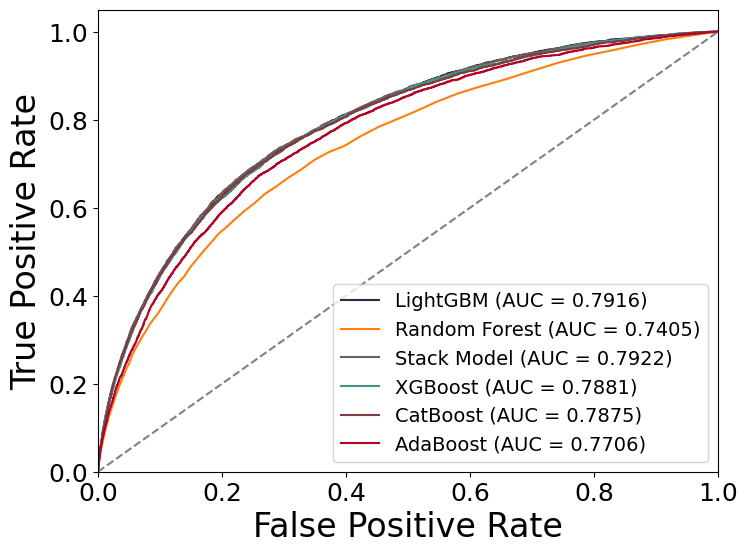

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_prob)
roc_auc_lgb = auc(fpr, tpr)

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_valid, rf_y_pred_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_ada, tpr_ada, thresholds_ada = roc_curve(y_valid, ada_y_pred_prob)
roc_auc_ada = auc(fpr_ada, tpr_ada)

fpr_cat, tpr_cat, thresholds_ada = roc_curve(y_valid, cat_y_pred_prob)
roc_auc_cat = auc(fpr_cat, tpr_cat)

fpr_xg, tpr_xg, thresholds_xg = roc_curve(y_valid, xgb_y_pred_prob)
roc_auc_xg = auc(fpr_xg, tpr_xg)

stack_pred_prob = stacker.predict_proba(np.vstack([y_pred_prob, xgb_y_pred_prob, cat_y_pred_prob]).T)[:, 1]
fpr_stack, tpr_stack, thresholds = roc_curve(y_valid, stack_pred_prob)
roc_auc_stack = auc(fpr_stack, tpr_stack)

# 绘制 ROC 曲线
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='#292d43', label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')      
plt.plot(fpr_rf, tpr_rf, color='#ff7f0e', label=f'Random Forest (AUC = {roc_auc_rf:.4f})')  
plt.plot(fpr_stack, tpr_stack, color='#705f5d', label=f'Stack Model (AUC = {roc_auc_stack:.4f})')  
plt.plot(fpr_xg, tpr_xg, color='#459289', label=f'XGBoost (AUC = {roc_auc_xg:.4f})')      
plt.plot(fpr_cat, tpr_cat, color='#7d3d41', label=f'CatBoost (AUC = {roc_auc_cat:.4f})')      
plt.plot(fpr_ada, tpr_ada, color='#b40426', label=f'AdaBoost (AUC = {roc_auc_ada:.4f})')   

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 随机猜测的基准线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate',fontsize=24)
plt.ylabel('True Positive Rate',fontsize=24)
# plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right',fontsize=14)
# Adjusting the tick parameters to set size of ticks
plt.tick_params(axis='both', which='major', labelsize=18)

# plt.show()

# 保存热力图
plt.savefig("auc_roc.pdf", bbox_inches='tight', dpi=300)